In [1]:
import numpy as np
import matplotlib.pyplot as plt
import LAMINAR
import torch

# import tsne
from sklearn.manifold import TSNE

In [2]:
# import newhalo_young_data_points.npy and newhalo_young_satellite_labels.npy

data = np.load('newhalo_young_data_points.npy')
labels = np.load('newhalo_young_satellite_labels.npy')


In [3]:
# check how many points are in each label and print in decreasing order
counts = np.bincount(labels)

counts_sorted = np.argsort(counts)[::-1]

for i in counts_sorted:
    print(f"Label {i}: {counts[i]} points")


Label 1066: 46814 points
Label 1377: 23970 points
Label 1228: 22094 points
Label 1068: 15477 points
Label 765: 13775 points
Label 24: 13337 points
Label 766: 11644 points
Label 1379: 9372 points
Label 28: 8824 points
Label 1224: 8419 points
Label 425: 6725 points
Label 1070: 2601 points
Label 1227: 2513 points
Label 433: 1837 points
Label 1376: 1344 points
Label 325: 1101 points
Label 19: 1070 points
Label 23: 984 points
Label 851: 936 points
Label 768: 922 points
Label 434: 860 points
Label 757: 600 points
Label 763: 552 points
Label 21: 448 points
Label 27: 406 points
Label 20: 364 points
Label 381: 233 points
Label 119: 217 points
Label 22: 191 points
Label 11: 189 points
Label 85: 167 points
Label 83: 150 points
Label 17: 141 points
Label 81: 139 points
Label 777: 113 points
Label 385: 112 points
Label 1073: 112 points
Label 383: 111 points
Label 329: 77 points
Label 13: 75 points
Label 226: 74 points
Label 158: 71 points
Label 125: 70 points
Label 324: 64 points
Label 156: 62 poin

In [4]:
counts_sorted_cum = np.cumsum(counts[counts_sorted])/len(data)

# print all labels until cumulative count is greater than 0.6

l = []

for i in range(max(labels)):
    if counts_sorted_cum[i] < 0.6:
        print(f"Label {counts_sorted[i]}: {counts[counts_sorted[i]]} points")
        l.append(counts_sorted[i])
        


Label 1066: 46814 points
Label 1377: 23970 points
Label 1228: 22094 points
Label 1068: 15477 points


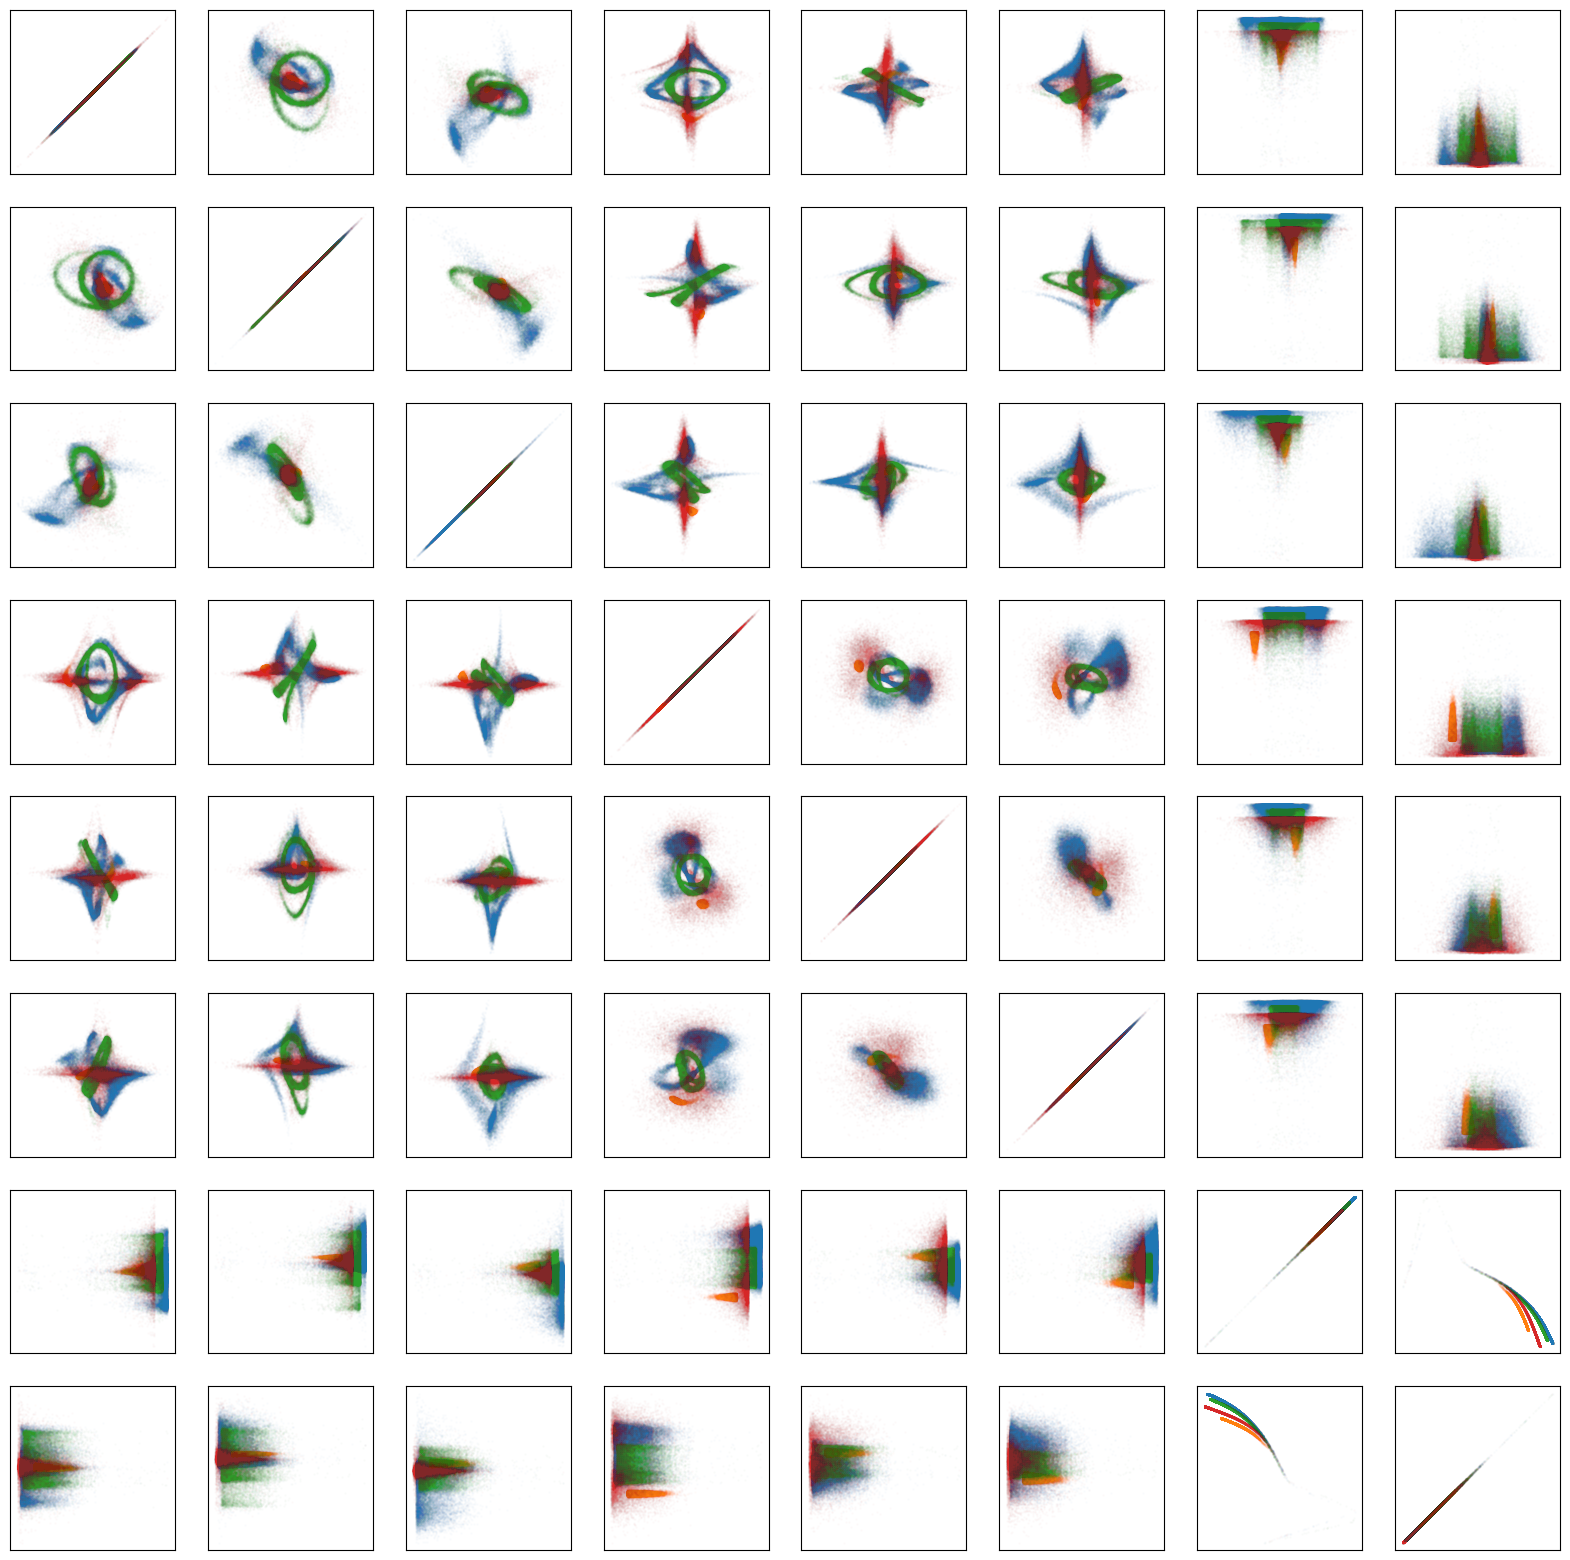

In [5]:
# plot the data for labels l in a 8 by 8 subplot grid
fig, axs = plt.subplots(8, 8, figsize=(20, 20))

for i in range(8):
    for j in range(8):
        for k in range(len(l)):
            axs[i, j].scatter(data[labels == l[k], i], data[labels == l[k], j], s=1, alpha=0.01)
            axs[i, j].set_xticks([])
            axs[i, j].set_yticks([])

# data_red is data with only the points in labels l
data_red = data[np.isin(labels, l)]

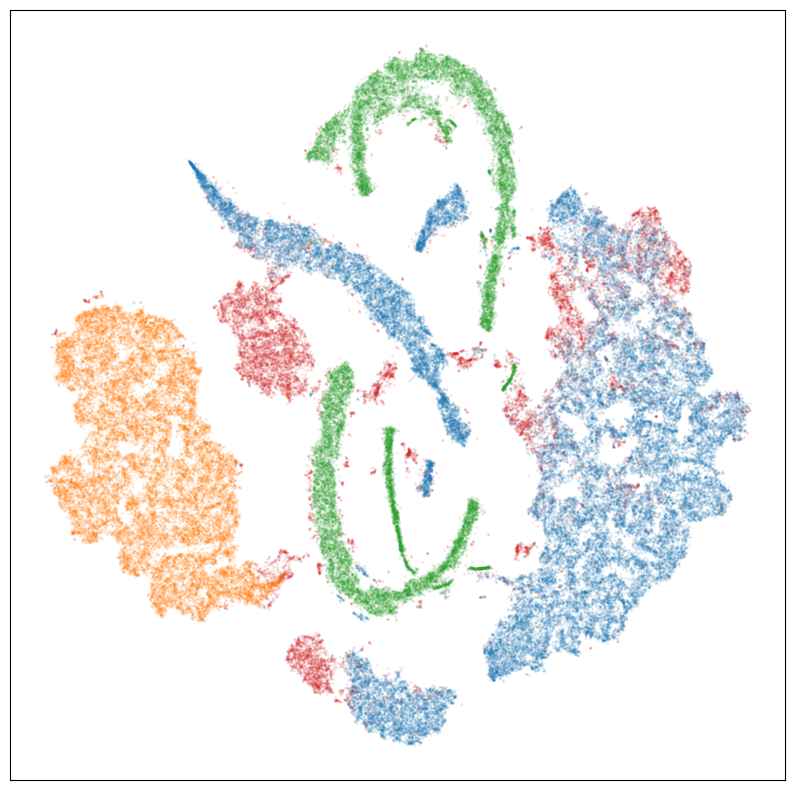

In [ ]:
# apply t-SNE to data_red
tsne = TSNE(n_components=2, random_state=0, perplexity=250)
data_red_tsne = tsne.fit_transform(data_red)

# plot the t-SNE data
fig, ax = plt.subplots(figsize=(10, 10))
for i in range(len(l)):
    ax.scatter(data_red_tsne[labels[np.isin(labels, l)] == l[i], 0], data_red_tsne[labels[np.isin(labels, l)] == l[i], 1], s=1, alpha=0.1)
    ax.set_xticks([])
    ax.set_yticks([])
    
plt.show()

# save the plot as a png file

fig.savefig('tsne_eucl_250.png', dpi=300)


In [ ]:
data_red = torch.tensor(data_red, dtype=torch.float32)
data_red = (data_red-data_red.mean())/data_red.std()

# random permutation of data_red
perm = torch.randperm(data_red.size(0))
data_red = data_red[perm]
labels_red = labels[np.isin(labels, l)][perm]

: 

In [ ]:
# train laminar on data_red
LAM = LAMINAR.LAMINAR(data_red, drop_freq=9999, epochs=2500)

Iteration 0 | Train Loss: 2764.861083984375 | Validation Loss: 2764.919189453125
Iteration 99 | Train Loss: 399.81182861328125 | Validation Loss: 398.81573486328125
Iteration 199 | Train Loss: -91.07704162597656 | Validation Loss: -102.2651138305664
Iteration 299 | Train Loss: -381.57684326171875 | Validation Loss: -376.5832824707031
Iteration 399 | Train Loss: -494.71575927734375 | Validation Loss: -504.206298828125
Iteration 499 | Train Loss: -369.8680114746094 | Validation Loss: -371.6540832519531
Iteration 599 | Train Loss: -663.4744262695312 | Validation Loss: -660.3108520507812
Iteration 699 | Train Loss: -357.8509216308594 | Validation Loss: -358.7528991699219
Iteration 799 | Train Loss: -649.6602783203125 | Validation Loss: -650.4674682617188
Iteration 899 | Train Loss: -633.7434692382812 | Validation Loss: -637.6310424804688
Iteration 999 | Train Loss: -451.676513671875 | Validation Loss: -461.1156311035156


In [ ]:
pushed = LAM.X_pushed

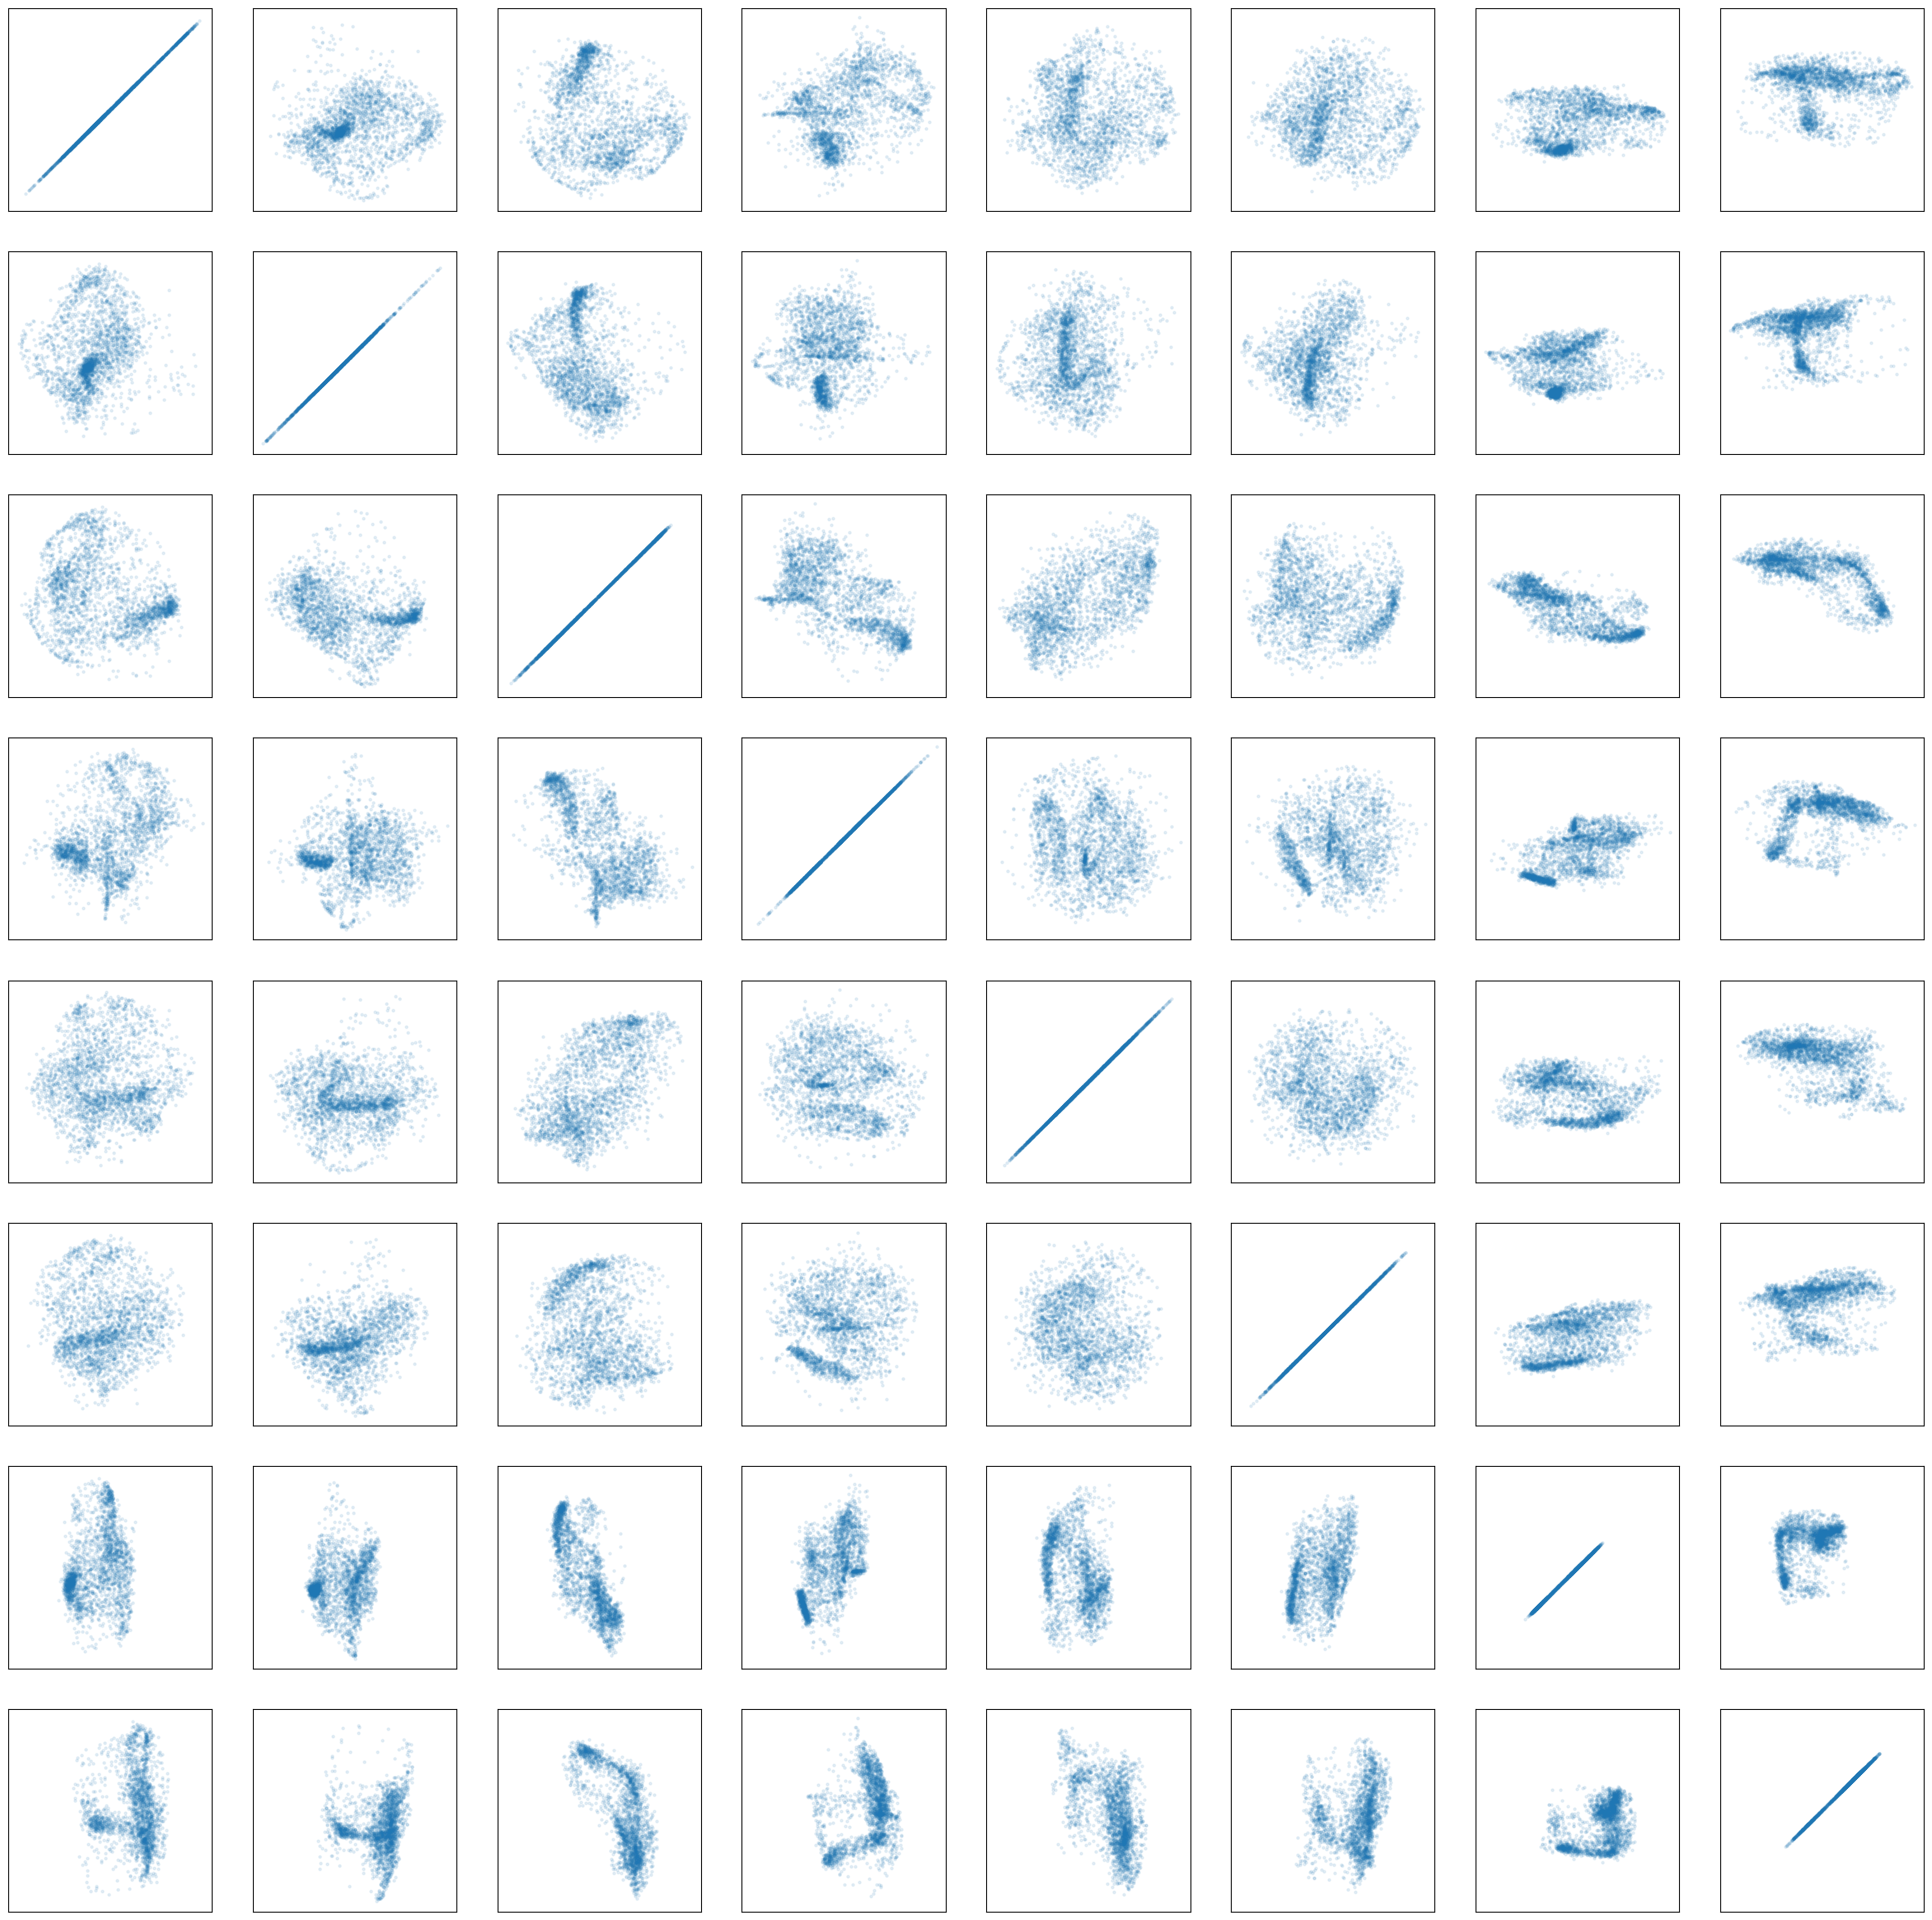

In [ ]:
fig, axs = plt.subplots(8, 8, figsize=(30, 30))

for i in range(8):
    for j in range(8):
        axs[i, j].scatter(pushed[:, i], pushed[:, j], s=5, alpha=0.1)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
        axs[i, j].set_xlim(-1, 1)
        axs[i, j].set_ylim(-1, 1)

# save the plot as a png file

fig.savefig('laminar_pushed.png', dpi=300)

In [ ]:
dists_matrix = LAM.dist_matrix

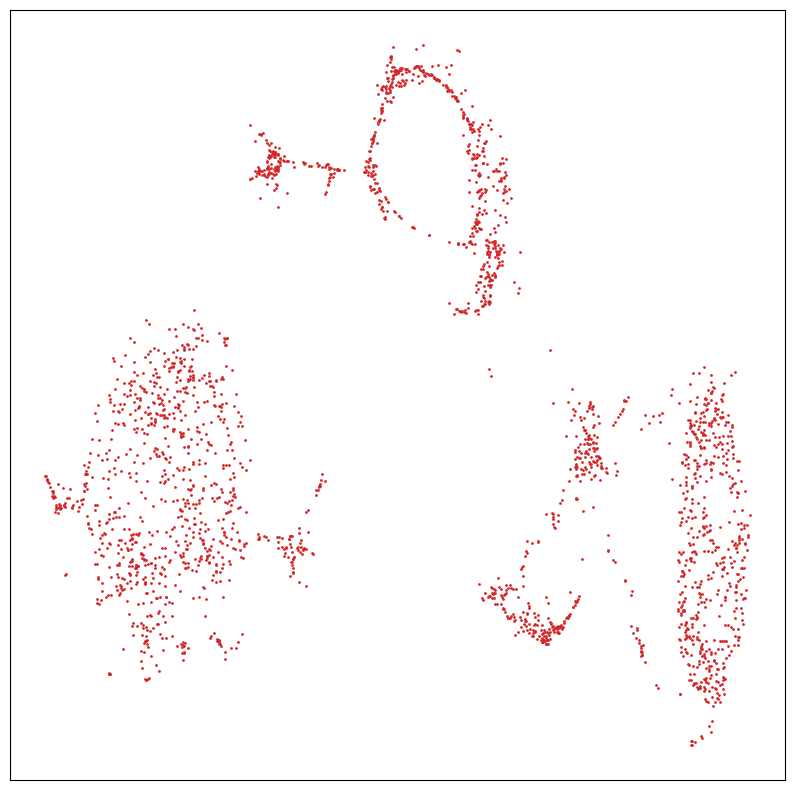

In [ ]:
for perp in [50, 100, 250, 500, 1000]:
    tsne = TSNE(n_components=2, random_state=0, perplexity=perp, metric='precomputed', init='random')
    dists_matrix_tsne = tsne.fit_transform(dists_matrix)

    fig, ax = plt.subplots(figsize=(10, 10))

    for i in range(len(l)):
        ax.scatter(dists_matrix_tsne[labels_red == l[i], 0], dists_matrix_tsne[labels_red == l[i], 1], s=1, alpha=1)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.show()

    # save the plot as a png file
    fig.savefig(f'tsne_lam_{perp}.png', dpi=300)
